# Deteksi Gender dan Estimasi Usia Berbasis Citra Wajah Menggunakan Convolutional Neural Network (CNN)

Notebook final ini disusun untuk memenuhi panduan UAS: data acquisition, cleaning/preprocessing, EDA, modeling dua model, evaluasi, interpretasi, visualisasi akhir, dan final training semua data.

**Framework:** PyTorch  
**Dataset:** UTKFace  
**Output:** gender dan estimasi usia

## 1. Setup Kaggle dan Import Library
Aktifkan GPU di Kaggle melalui `Settings -> Accelerator -> GPU` sebelum menjalankan notebook.

In [52]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, mean_absolute_error, mean_squared_error,
)

print("PyTorch:", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.10.0+cu128
CUDA tersedia: True
Device: cuda


## 2. Konfigurasi Training
Gunakan `USE_SUBSET=True` untuk uji coba cepat. Untuk training semua dataset, gunakan `USE_SUBSET=False`.

In [76]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

IMAGE_SIZE = 224
BATCH_SIZE = 32  # Gunakan 16 jika GPU memory error, 64 jika GPU kuat
NUM_WORKERS = 2
AGE_MAX = 116.0

USE_SUBSET = False
MAX_SAMPLES = 5000

EPOCHS_SIMPLECNN = 10
EPOCHS_RESNET18 = 25
EPOCHS_FINAL = 30

USE_PRETRAINED_RESNET = True
LR = 1e-4
AGE_LOSS_WEIGHT = 0.05

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
MODEL_DIR = WORK_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
print("WORK_DIR:", WORK_DIR)

FIG_DIR = WORK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Folder model:", MODEL_DIR)
print("Folder gambar/grafik:", FIG_DIR)

WORK_DIR: /kaggle/working
Folder model: /kaggle/working/models
Folder gambar/grafik: /kaggle/working/figures


## 3. Data Acquisition dan Pencarian Dataset
Dataset UTKFace menyimpan label pada nama file: `age_gender_race_datetime.jpg`.

In [54]:
INPUT_DIR = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path("data")
valid_ext = {".jpg", ".jpeg", ".png"}

image_paths = [p for p in INPUT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in valid_ext]
print("Jumlah semua file gambar ditemukan:", len(image_paths))

valid_utk_paths = []
for p in image_paths:
    try:
        parts = p.stem.split("_")
        age = int(parts[0])
        gender = int(parts[1])
        if 0 <= age <= int(AGE_MAX) and gender in [0, 1]:
            valid_utk_paths.append(p)
    except Exception:
        continue

print("Jumlah gambar valid format UTKFace:", len(valid_utk_paths))

if len(valid_utk_paths) == 0:
    print("Dataset UTKFace belum ditemukan.")
    print("Daftar folder:")
    for p in INPUT_DIR.rglob("*"):
        if p.is_dir():
            print("-", p)
    raise ValueError("Tambahkan dataset UTKFace melalui Add Data di Kaggle.")

parent_counts = Counter([p.parent for p in valid_utk_paths])
DATA_DIR = parent_counts.most_common(1)[0][0]
print("DATA_DIR yang dipakai:", DATA_DIR)
print("Jumlah gambar valid di folder ini:", parent_counts[DATA_DIR])

Jumlah semua file gambar ditemukan: 66976
Jumlah gambar valid format UTKFace: 66974
DATA_DIR yang dipakai: /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
Jumlah gambar valid di folder ini: 23708


## 4. Data Cleaning dan Pembuatan Metadata CSV

In [55]:
def build_metadata(data_dir: Path) -> pd.DataFrame:
    rows = []
    invalid_files = []
    image_paths = [p for p in data_dir.rglob("*") if p.is_file() and p.suffix.lower() in valid_ext]
    print("Jumlah file gambar ditemukan di DATA_DIR:", len(image_paths))

    for img_path in image_paths:
        try:
            parts = img_path.stem.split("_")
            if len(parts) < 2:
                invalid_files.append((img_path.name, "format nama tidak valid"))
                continue
            age = int(parts[0])
            gender = int(parts[1])
            if age < 0 or age > int(AGE_MAX):
                invalid_files.append((img_path.name, "usia tidak valid"))
                continue
            if gender not in [0, 1]:
                invalid_files.append((img_path.name, "gender tidak valid"))
                continue
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                invalid_files.append((img_path.name, "gambar corrupt/rusak"))
                continue
            rows.append({
                "image_path": str(img_path),
                "filename": img_path.name,
                "age": age,
                "gender": gender,
                "gender_label": "Male" if gender == 0 else "Female",
            })
        except Exception as e:
            invalid_files.append((img_path.name, str(e)))

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.drop_duplicates(subset=["image_path"])
        df = df.dropna(subset=["image_path", "age", "gender"])
        df["age"] = df["age"].astype(int)
        df["gender"] = df["gender"].astype(int)

    invalid_df = pd.DataFrame(invalid_files, columns=["filename", "reason"])
    invalid_df.to_csv(WORK_DIR / "invalid_files.csv", index=False)
    df.to_csv(WORK_DIR / "labels_clean.csv", index=False)
    print("Jumlah data valid:", len(df))
    print("Jumlah file bermasalah:", len(invalid_df))
    return df

df = build_metadata(DATA_DIR)
df.head()

Jumlah file gambar ditemukan di DATA_DIR: 23708
Jumlah data valid: 23708
Jumlah file bermasalah: 0


,image_path,filename,age,gender,gender_label
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26_0_2_20170104023102422.jpg.chip.jpg,26,0,Male
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22_1_1_20170112233644761.jpg.chip.jpg,22,1,Female
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21_1_3_20170105003215901.jpg.chip.jpg,21,1,Female
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28_0_0_20170117180555824.jpg.chip.jpg,28,0,Male
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17_1_4_20170103222931966.jpg.chip.jpg,17,1,Female


## 5. Exploratory Data Analysis (EDA)

In [56]:
print(df.info())
print(df.describe())
print("Missing value:")
print(df.isna().sum())
print("Distribusi gender:")
print(df["gender_label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_path    23708 non-null  object
 1   filename      23708 non-null  object
 2   age           23708 non-null  int64 
 3   gender        23708 non-null  int64 
 4   gender_label  23708 non-null  object
dtypes: int64(2), object(3)
memory usage: 926.2+ KB
None
                age        gender
count  23708.000000  23708.000000
mean      33.303484      0.477349
std       19.886112      0.499497
min        1.000000      0.000000
25%       23.000000      0.000000
50%       29.000000      0.000000
75%       45.000000      1.000000
max      116.000000      1.000000
Missing value:
image_path      0
filename        0
age             0
gender          0
gender_label    0
dtype: int64
Distribusi gender:
gender_label
Male      12391
Female    11317
Name: count, dtype: int64


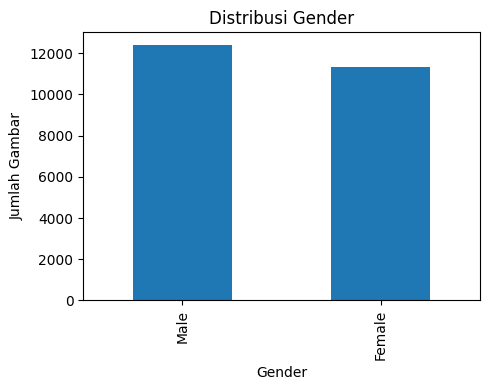

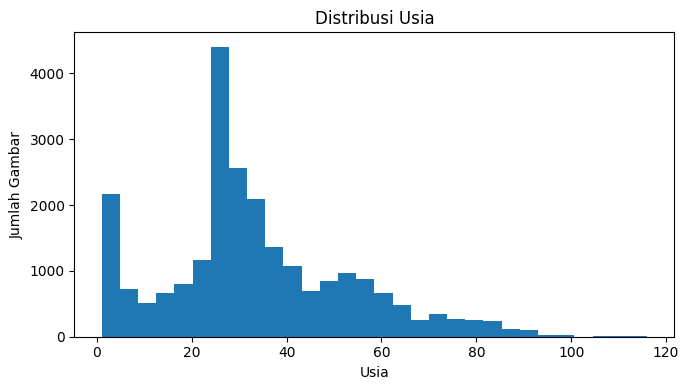

<Figure size 600x400 with 0 Axes>

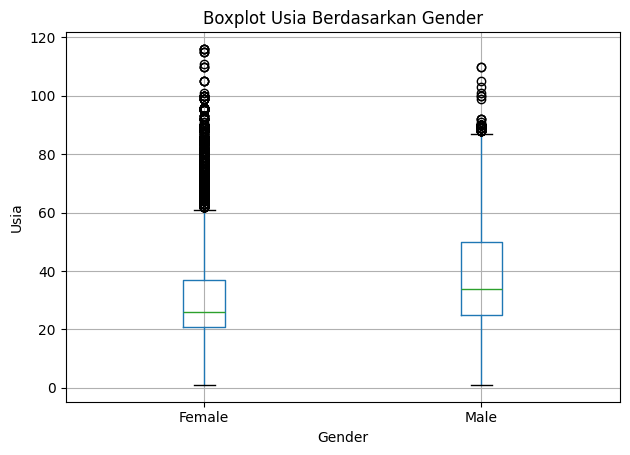

In [77]:
# Grafik 1: Distribusi Gender
plt.figure(figsize=(5, 4))
df["gender_label"].value_counts().plot(kind="bar")
plt.title("Distribusi Gender")
plt.xlabel("Gender")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribusi_gender.png", dpi=300, bbox_inches="tight")
plt.show()

# Grafik 2: Distribusi Usia
plt.figure(figsize=(7, 4))
plt.hist(df["age"], bins=30)
plt.title("Distribusi Usia")
plt.xlabel("Usia")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_distribusi_usia.png", dpi=300, bbox_inches="tight")
plt.show()

# Grafik 3: Boxplot Usia Berdasarkan Gender
plt.figure(figsize=(6, 4))
df.boxplot(column="age", by="gender_label")
plt.title("Boxplot Usia Berdasarkan Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Usia")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_boxplot_usia_gender.png", dpi=300, bbox_inches="tight")
plt.show()

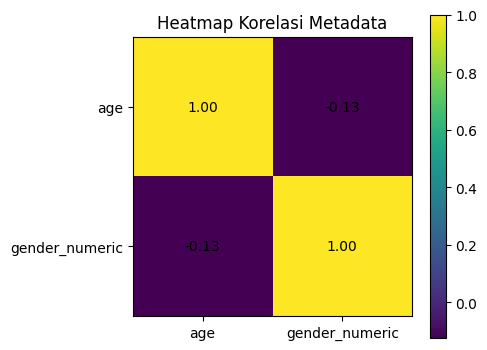

In [78]:
eda_df = df.copy()
eda_df["gender_numeric"] = eda_df["gender"]

corr = eda_df[["age", "gender_numeric"]].corr()

plt.figure(figsize=(5, 4))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Heatmap Korelasi Metadata")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_heatmap_korelasi_metadata.png", dpi=300, bbox_inches="tight")
plt.show()

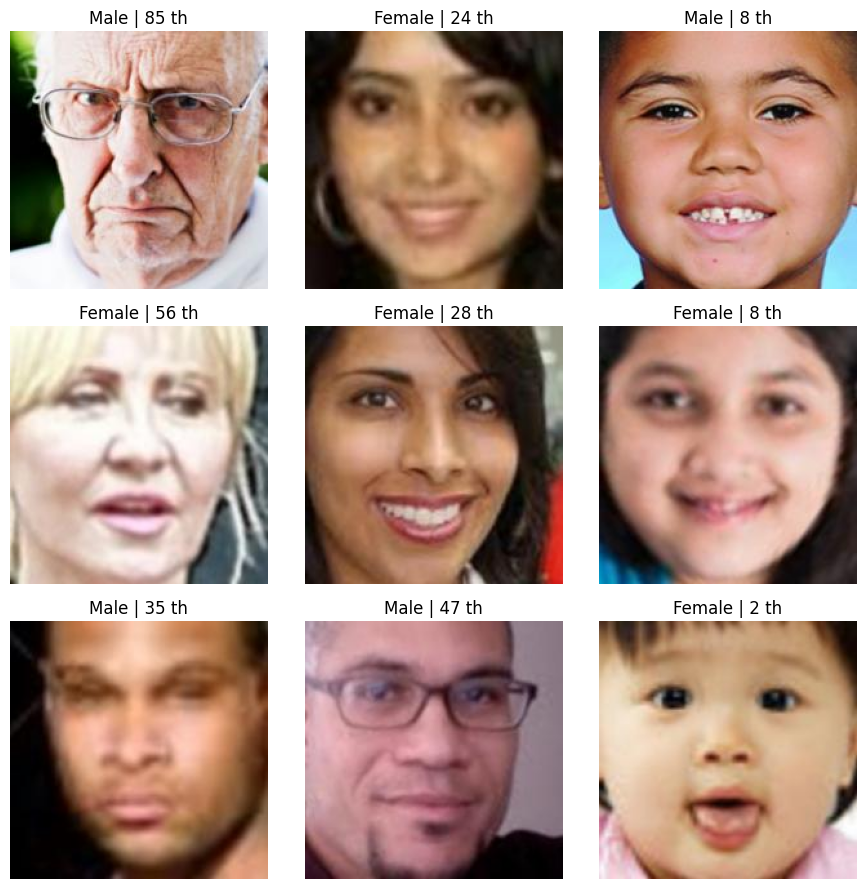

In [79]:
sample_df = df.sample(min(9, len(df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(9, 9))

for i, row in sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{row['gender_label']} | {row['age']} th")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_contoh_gambar_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight Awal EDA
Distribusi gender dan usia digunakan untuk mengetahui keseimbangan data. Jika kelompok usia tertentu dominan, model dapat lebih akurat pada kelompok tersebut dan kurang akurat pada kelompok usia yang jarang muncul.

## 6. Preprocessing dan Split Data

In [60]:
df_work = df.copy().reset_index(drop=True)
if USE_SUBSET and len(df_work) > MAX_SAMPLES:
    df_work = df_work.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

df_work["age_group"] = pd.cut(
    df_work["age"],
    bins=[0, 12, 18, 30, 45, 60, 80, 120],
    labels=["0-12", "13-18", "19-30", "31-45", "46-60", "61-80", "80+"],
    include_lowest=True,
)
df_work["stratify_col"] = df_work["gender"].astype(str) + "_" + df_work["age_group"].astype(str)
strat_counts = df_work["stratify_col"].value_counts()
stratify_first = df_work["gender"] if (strat_counts < 2).any() else df_work["stratify_col"]

train_df, temp_df = train_test_split(df_work, test_size=0.30, random_state=SEED, stratify=stratify_first)
temp_counts = temp_df["stratify_col"].value_counts()
stratify_second = temp_df["gender"] if (temp_counts < 2).any() else temp_df["stratify_col"]
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=stratify_second)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))

Train: 16595 Validation: 3556 Test: 3557


In [61]:
from torchvision import transforms

# Transform training memakai augmentasi agar model lebih tahan terhadap variasi kamera.
# Normalize memakai mean/std ImageNet karena ResNet18 pretrained dilatih dengan standar ini.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform validasi/test tanpa augmentasi agar evaluasi stabil.
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class FaceAgeGenderDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            img = Image.open(row["image_path"]).convert("RGB")
        except Exception:
            # Pengaman jika masih ada gambar corrupt yang lolos saat cleaning.
            img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), color=(0, 0, 0))

        if self.transform is not None:
            img = self.transform(img)

        gender = torch.tensor(int(row["gender"]), dtype=torch.long)
        age = torch.tensor(float(row["age"]), dtype=torch.float32)

        return img, gender, age


train_ds = FaceAgeGenderDataset(train_df, train_transform)
val_ds = FaceAgeGenderDataset(val_df, val_transform)
test_ds = FaceAgeGenderDataset(test_df, val_transform)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Jumlah batch train:", len(train_loader))
print("Jumlah batch validasi:", len(val_loader))
print("Jumlah batch test:", len(test_loader))


Jumlah batch train: 519
Jumlah batch validasi: 112
Jumlah batch test: 112


## 7. Model 1: SimpleCNN

In [62]:
class SimpleCNN(nn.Module):
    def __init__(self, age_max: float = 116.0):
        super().__init__()
        self.age_max = age_max
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.shared = nn.Sequential(nn.Flatten(), nn.Dropout(0.30), nn.Linear(256, 128), nn.ReLU(inplace=True))
        self.gender_head = nn.Linear(128, 2)
        self.age_head = nn.Linear(128, 1)
    def forward(self, x):
        x = self.features(x)
        x = self.shared(x)
        gender_logits = self.gender_head(x)
        age_years = torch.sigmoid(self.age_head(x)).squeeze(1) * self.age_max
        return gender_logits, age_years

## 8. Model 2: ResNet18 Multi-Task

In [63]:
class ResNet18MultiTask(nn.Module):
    def __init__(self, pretrained: bool = False, age_max: float = 116.0):
        super().__init__()
        self.age_max = age_max
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.shared = nn.Sequential(nn.Dropout(0.30), nn.Linear(in_features, 256), nn.ReLU(inplace=True))
        self.gender_head = nn.Linear(256, 2)
        self.age_head = nn.Linear(256, 1)
    def forward(self, x):
        x = self.backbone(x)
        x = self.shared(x)
        gender_logits = self.gender_head(x)
        age_years = torch.sigmoid(self.age_head(x)).squeeze(1) * self.age_max
        return gender_logits, age_years

## 9. Fungsi Training dan Evaluasi

In [64]:
def train_one_epoch(model, loader, optimizer, gender_criterion, age_criterion):
    model.train()
    total_loss = 0.0
    all_gender_true, all_gender_pred = [], []
    all_age_true, all_age_pred = [], []
    for images, genders, ages in loader:
        images, genders, ages = images.to(device), genders.to(device), ages.to(device)
        optimizer.zero_grad()
        gender_logits, age_preds = model(images)
        gender_loss = gender_criterion(gender_logits, genders)
        age_loss = age_criterion(age_preds, ages)
        loss = gender_loss + AGE_LOSS_WEIGHT * age_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(gender_logits, dim=1)
        all_gender_true.extend(genders.detach().cpu().numpy().tolist())
        all_gender_pred.extend(preds.detach().cpu().numpy().tolist())
        all_age_true.extend(ages.detach().cpu().numpy().tolist())
        all_age_pred.extend(age_preds.detach().cpu().numpy().tolist())
    return total_loss / len(loader.dataset), accuracy_score(all_gender_true, all_gender_pred), mean_absolute_error(all_age_true, all_age_pred)


def evaluate_model(model, loader):
    model.eval()
    all_gender_true, all_gender_pred, all_gender_prob = [], [], []
    all_age_true, all_age_pred = [], []
    with torch.no_grad():
        for images, genders, ages in loader:
            images, genders, ages = images.to(device), genders.to(device), ages.to(device)
            gender_logits, age_preds = model(images)
            probs = torch.softmax(gender_logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_gender_true.extend(genders.cpu().numpy().tolist())
            all_gender_pred.extend(preds.cpu().numpy().tolist())
            all_gender_prob.extend(probs[:, 1].cpu().numpy().tolist())
            all_age_true.extend(ages.cpu().numpy().tolist())
            all_age_pred.extend(age_preds.cpu().numpy().tolist())
    try:
        auc = roc_auc_score(all_gender_true, all_gender_prob)
    except Exception:
        auc = np.nan
    return {
        "gender_accuracy": accuracy_score(all_gender_true, all_gender_pred),
        "gender_precision": precision_score(all_gender_true, all_gender_pred, zero_division=0),
        "gender_recall": recall_score(all_gender_true, all_gender_pred, zero_division=0),
        "gender_f1": f1_score(all_gender_true, all_gender_pred, zero_division=0),
        "gender_auc_roc": auc,
        "age_mae": mean_absolute_error(all_age_true, all_age_pred),
        "age_rmse": float(np.sqrt(mean_squared_error(all_age_true, all_age_pred))),
        "confusion_matrix": confusion_matrix(all_gender_true, all_gender_pred),
        "gender_true": all_gender_true,
        "gender_pred": all_gender_pred,
        "gender_prob": all_gender_prob,
        "age_true": all_age_true,
        "age_pred": all_age_pred,
    }


def fit_model(model, train_loader, val_loader=None, epochs=5, lr=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    gender_criterion = nn.CrossEntropyLoss()
    age_criterion = nn.L1Loss()
    history = {"train_loss": [], "train_gender_acc": [], "train_age_mae": [], "val_gender_acc": [], "val_age_mae": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_mae = train_one_epoch(model, train_loader, optimizer, gender_criterion, age_criterion)
        history["train_loss"].append(train_loss)
        history["train_gender_acc"].append(train_acc)
        history["train_age_mae"].append(train_mae)
        if val_loader is not None:
            val_metrics = evaluate_model(model, val_loader)
            history["val_gender_acc"].append(val_metrics["gender_accuracy"])
            history["val_age_mae"].append(val_metrics["age_mae"])
            print(f"Epoch {epoch}/{epochs} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_metrics['gender_accuracy']:.4f} | train_age_mae={train_mae:.2f} | val_age_mae={val_metrics['age_mae']:.2f}")
        else:
            print(f"Epoch {epoch}/{epochs} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_age_mae={train_mae:.2f}")
    return model, history

## 10. Training Model 1: SimpleCNN

In [65]:
simple_model = SimpleCNN(age_max=AGE_MAX)
simple_model, hist_simple = fit_model(simple_model, train_loader, val_loader, epochs=EPOCHS_SIMPLECNN, lr=LR)
simple_test = evaluate_model(simple_model, test_loader)
simple_test

Epoch 1/10 | loss=1.3696 | train_acc=0.6282 | val_acc=0.6699 | train_age_mae=14.49 | val_age_mae=13.64
Epoch 2/10 | loss=1.2654 | train_acc=0.6727 | val_acc=0.6963 | train_age_mae=13.21 | val_age_mae=14.80
Epoch 3/10 | loss=1.2023 | train_acc=0.7029 | val_acc=0.7295 | train_age_mae=12.56 | val_age_mae=11.61
Epoch 4/10 | loss=1.1557 | train_acc=0.7179 | val_acc=0.7522 | train_age_mae=12.08 | val_age_mae=11.78
Epoch 5/10 | loss=1.1134 | train_acc=0.7328 | val_acc=0.7393 | train_age_mae=11.59 | val_age_mae=11.33
Epoch 6/10 | loss=1.0796 | train_acc=0.7444 | val_acc=0.7747 | train_age_mae=11.25 | val_age_mae=11.29
Epoch 7/10 | loss=1.0572 | train_acc=0.7543 | val_acc=0.7866 | train_age_mae=11.04 | val_age_mae=10.55
Epoch 8/10 | loss=1.0273 | train_acc=0.7655 | val_acc=0.7961 | train_age_mae=10.82 | val_age_mae=11.31
Epoch 9/10 | loss=1.0063 | train_acc=0.7730 | val_acc=0.7922 | train_age_mae=10.56 | val_age_mae=11.02
Epoch 10/10 | loss=0.9908 | train_acc=0.7749 | val_acc=0.7919 | train_age

{'gender_accuracy': 0.7883047511948271,
 'gender_precision': 0.8620689655172413,
 'gender_recall': 0.6625441696113075,
 'gender_f1': 0.7492507492507493,
 'gender_auc_roc': np.float64(0.8824212391757921),
 'age_mae': 9.495007300874574,
 'age_rmse': 13.199395498700202,
 'confusion_matrix': array([[1679,  180],
        [ 573, 1125]]),
 'gender_true': [1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
 

## 11. Training Model 2: ResNet18

In [69]:
resnet_model = ResNet18MultiTask(pretrained=USE_PRETRAINED_RESNET, age_max=AGE_MAX)
resnet_model, hist_resnet = fit_model(resnet_model, train_loader, val_loader, epochs=EPOCHS_RESNET18, lr=LR)
resnet_test = evaluate_model(resnet_model, test_loader)
resnet_test

Epoch 1/25 | loss=0.7140 | train_acc=0.8657 | val_acc=0.8735 | train_age_mae=8.18 | val_age_mae=6.28
Epoch 2/25 | loss=0.5229 | train_acc=0.9122 | val_acc=0.9263 | train_age_mae=6.39 | val_age_mae=5.60
Epoch 3/25 | loss=0.4775 | train_acc=0.9230 | val_acc=0.9339 | train_age_mae=5.90 | val_age_mae=5.41
Epoch 4/25 | loss=0.4399 | train_acc=0.9363 | val_acc=0.9421 | train_age_mae=5.61 | val_age_mae=5.49
Epoch 5/25 | loss=0.4144 | train_acc=0.9418 | val_acc=0.9376 | train_age_mae=5.35 | val_age_mae=5.53
Epoch 6/25 | loss=0.3888 | train_acc=0.9497 | val_acc=0.9367 | train_age_mae=5.14 | val_age_mae=5.15
Epoch 7/25 | loss=0.3715 | train_acc=0.9534 | val_acc=0.9345 | train_age_mae=5.02 | val_age_mae=5.18
Epoch 8/25 | loss=0.3542 | train_acc=0.9572 | val_acc=0.9387 | train_age_mae=4.84 | val_age_mae=5.10
Epoch 9/25 | loss=0.3306 | train_acc=0.9638 | val_acc=0.9412 | train_age_mae=4.69 | val_age_mae=5.09
Epoch 10/25 | loss=0.3198 | train_acc=0.9671 | val_acc=0.9395 | train_age_mae=4.58 | val_ag

{'gender_accuracy': 0.9271858307562553,
 'gender_precision': 0.9190448456610367,
 'gender_recall': 0.9293286219081273,
 'gender_f1': 0.9241581259150805,
 'gender_auc_roc': np.float64(0.9758346211186657),
 'age_mae': 4.873413012600495,
 'age_rmse': 7.0602667078500625,
 'confusion_matrix': array([[1720,  139],
        [ 120, 1578]]),
 'gender_true': [1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
 

## 12. Perbandingan Model dan Visualisasi Evaluasi

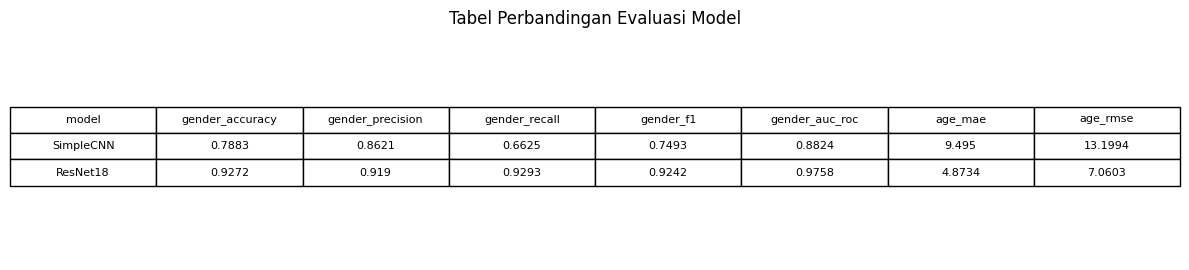

In [80]:
results_df = pd.DataFrame([
    {"model": "SimpleCNN", "gender_accuracy": simple_test["gender_accuracy"], "gender_precision": simple_test["gender_precision"], "gender_recall": simple_test["gender_recall"], "gender_f1": simple_test["gender_f1"], "gender_auc_roc": simple_test["gender_auc_roc"], "age_mae": simple_test["age_mae"], "age_rmse": simple_test["age_rmse"]},
    {"model": "ResNet18", "gender_accuracy": resnet_test["gender_accuracy"], "gender_precision": resnet_test["gender_precision"], "gender_recall": resnet_test["gender_recall"], "gender_f1": resnet_test["gender_f1"], "gender_auc_roc": resnet_test["gender_auc_roc"], "age_mae": resnet_test["age_mae"], "age_rmse": resnet_test["age_rmse"]},
])
results_df.to_csv(WORK_DIR / "comparison_results.csv", index=False)
results_df
# Simpan tabel perbandingan model sebagai gambar PNG
table_df = results_df.copy()

for col in table_df.columns:
    if col != "model":
        table_df[col] = table_df[col].astype(float).round(4)

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

plt.title("Tabel Perbandingan Evaluasi Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_tabel_perbandingan_model.png", dpi=300, bbox_inches="tight")
plt.show()

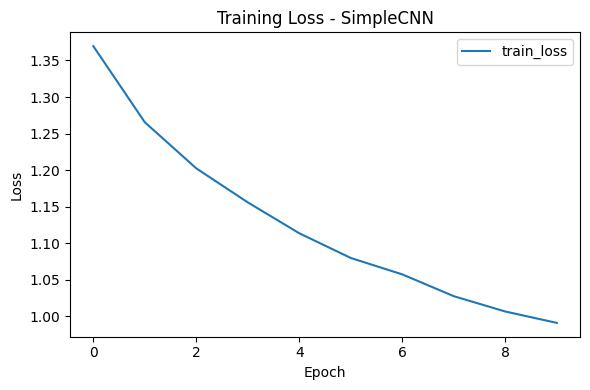

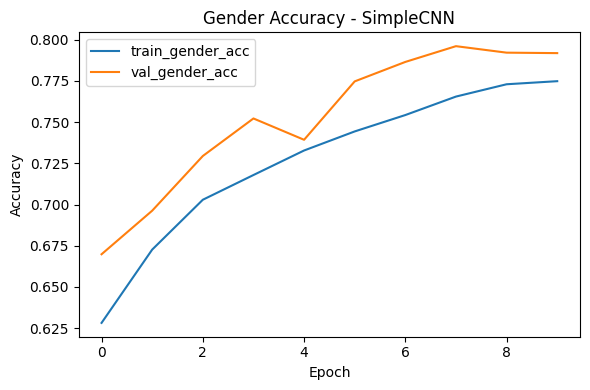

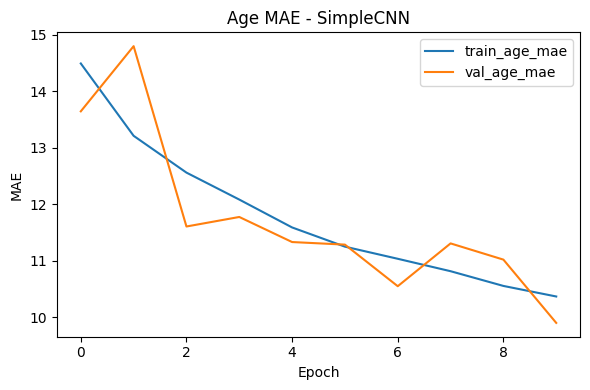

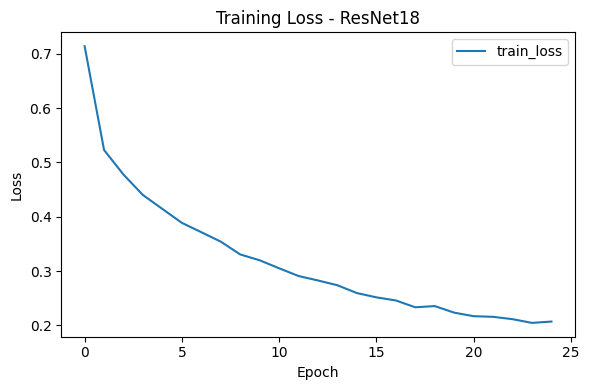

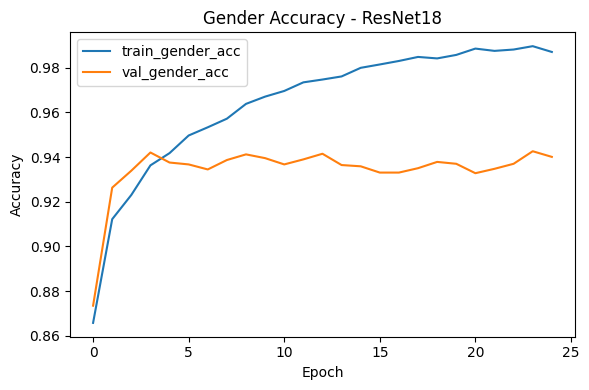

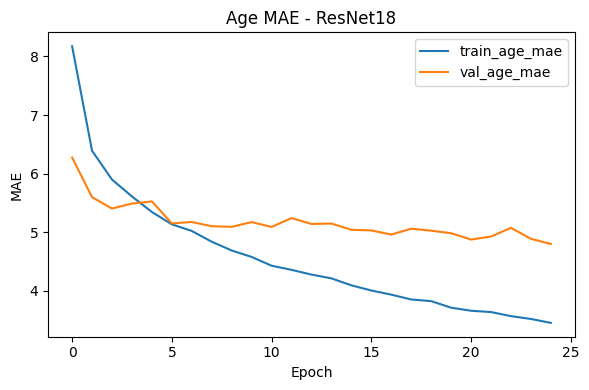

In [81]:
def plot_history(history, title):
    safe_title = title.lower().replace(" ", "_")

    # Grafik loss
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.title(f"Training Loss - {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"07_loss_{safe_title}.png", dpi=300, bbox_inches="tight")
    plt.show()

    if len(history["val_gender_acc"]) > 0:
        # Grafik gender accuracy
        plt.figure(figsize=(6, 4))
        plt.plot(history["train_gender_acc"], label="train_gender_acc")
        plt.plot(history["val_gender_acc"], label="val_gender_acc")
        plt.title(f"Gender Accuracy - {title}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"08_gender_accuracy_{safe_title}.png", dpi=300, bbox_inches="tight")
        plt.show()

        # Grafik age MAE
        plt.figure(figsize=(6, 4))
        plt.plot(history["train_age_mae"], label="train_age_mae")
        plt.plot(history["val_age_mae"], label="val_age_mae")
        plt.title(f"Age MAE - {title}")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"09_age_mae_{safe_title}.png", dpi=300, bbox_inches="tight")
        plt.show()


plot_history(hist_simple, "SimpleCNN")
plot_history(hist_resnet, "ResNet18")

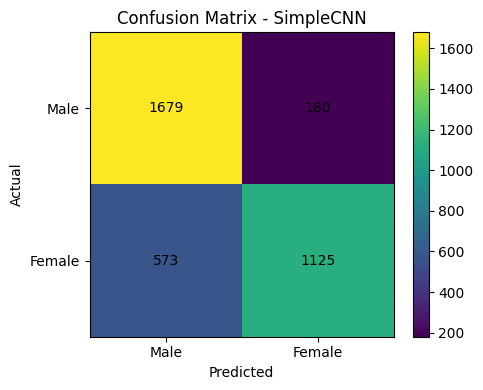

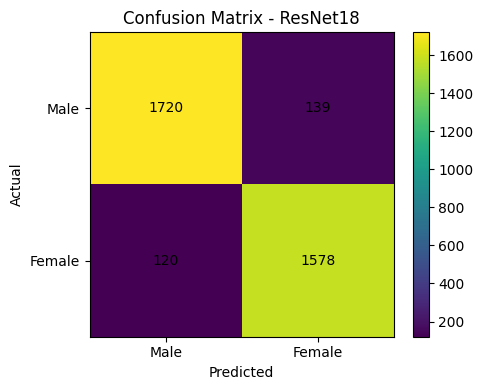

Classification Report SimpleCNN
              precision    recall  f1-score   support

        Male       0.75      0.90      0.82      1859
      Female       0.86      0.66      0.75      1698

    accuracy                           0.79      3557
   macro avg       0.80      0.78      0.78      3557
weighted avg       0.80      0.79      0.78      3557

Classification Report ResNet18
              precision    recall  f1-score   support

        Male       0.93      0.93      0.93      1859
      Female       0.92      0.93      0.92      1698

    accuracy                           0.93      3557
   macro avg       0.93      0.93      0.93      3557
weighted avg       0.93      0.93      0.93      3557



In [82]:
def plot_confusion_matrix(cm, title, filename):
    labels = ["Male", "Female"]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.xticks(range(2), labels)
    plt.yticks(range(2), labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(
    simple_test["confusion_matrix"],
    "Confusion Matrix - SimpleCNN",
    "10_confusion_matrix_simplecnn.png"
)

plot_confusion_matrix(
    resnet_test["confusion_matrix"],
    "Confusion Matrix - ResNet18",
    "11_confusion_matrix_resnet18.png"
)

print("Classification Report SimpleCNN")
print(classification_report(
    simple_test["gender_true"],
    simple_test["gender_pred"],
    target_names=["Male", "Female"],
    zero_division=0
))

print("Classification Report ResNet18")
print(classification_report(
    resnet_test["gender_true"],
    resnet_test["gender_pred"],
    target_names=["Male", "Female"],
    zero_division=0
))

## 13. Interpretasi Hasil
Model terbaik dipilih berdasarkan kombinasi F1-score gender tertinggi dan Age MAE terendah. Karena input berupa citra wajah, fitur yang dipelajari CNN adalah pola visual seperti bentuk wajah, area mata, rambut, tekstur kulit, kerutan, dan area mulut.

In [73]:
best_row = results_df.sort_values(by=["gender_f1", "age_mae"], ascending=[False, True]).iloc[0]
best_model_name = best_row["model"]
print("Model terbaik:", best_model_name)
print(best_row)

Model terbaik: ResNet18
model               ResNet18
gender_accuracy     0.927186
gender_precision    0.919045
gender_recall       0.929329
gender_f1           0.924158
gender_auc_roc      0.975835
age_mae             4.873413
age_rmse            7.060267
Name: 1, dtype: object


## 14. Final Training Menggunakan Semua Dataset
Metrik evaluasi yang dilaporkan tetap berasal dari test set. Final training digunakan untuk menghasilkan model akhir yang dipakai pada aplikasi demo.

In [74]:
final_df = df_work.copy().reset_index(drop=True)
final_ds = FaceAgeGenderDataset(final_df, train_transform)
final_loader = DataLoader(final_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

if best_model_name == "SimpleCNN":
    final_model = SimpleCNN(age_max=AGE_MAX)
else:
    final_model = ResNet18MultiTask(pretrained=USE_PRETRAINED_RESNET, age_max=AGE_MAX)

final_model, hist_final = fit_model(final_model, final_loader, val_loader=None, epochs=EPOCHS_FINAL, lr=LR)

final_model_path = MODEL_DIR / "final_gender_age_model.pth"
torch.save({
    "model_name": str(best_model_name),
    "model_state_dict": final_model.state_dict(),
    "image_size": IMAGE_SIZE,
    "age_max": AGE_MAX,
    "gender_labels": ["Laki-laki", "Perempuan"],
    "results": results_df.to_dict(orient="records"),
}, final_model_path)
print("Model final disimpan di:", final_model_path)

Epoch 1/30 | loss=0.6770 | train_acc=0.8732 | train_age_mae=7.86
Epoch 2/30 | loss=0.5017 | train_acc=0.9206 | train_age_mae=6.16
Epoch 3/30 | loss=0.4565 | train_acc=0.9310 | train_age_mae=5.71
Epoch 4/30 | loss=0.4231 | train_acc=0.9398 | train_age_mae=5.42
Epoch 5/30 | loss=0.3962 | train_acc=0.9479 | train_age_mae=5.20
Epoch 6/30 | loss=0.3783 | train_acc=0.9498 | train_age_mae=4.99
Epoch 7/30 | loss=0.3626 | train_acc=0.9554 | train_age_mae=4.87
Epoch 8/30 | loss=0.3434 | train_acc=0.9604 | train_age_mae=4.72
Epoch 9/30 | loss=0.3329 | train_acc=0.9622 | train_age_mae=4.60
Epoch 10/30 | loss=0.3167 | train_acc=0.9660 | train_age_mae=4.51
Epoch 11/30 | loss=0.3036 | train_acc=0.9701 | train_age_mae=4.40
Epoch 12/30 | loss=0.2926 | train_acc=0.9713 | train_age_mae=4.31
Epoch 13/30 | loss=0.2788 | train_acc=0.9749 | train_age_mae=4.20
Epoch 14/30 | loss=0.2713 | train_acc=0.9774 | train_age_mae=4.15
Epoch 15/30 | loss=0.2579 | train_acc=0.9797 | train_age_mae=4.04
Epoch 16/30 | loss=

## 15. Inference Gambar Tunggal

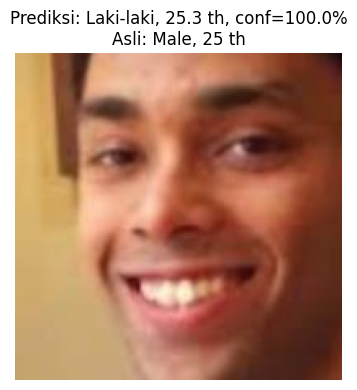

In [83]:
def predict_image(model, image_path):
    model.eval()
    pil_img = Image.open(image_path).convert("RGB")
    x = val_transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        gender_logits, age_pred = model(x)
        prob = torch.softmax(gender_logits, dim=1)[0]
        gender_idx = int(torch.argmax(prob).item())
        confidence = float(prob[gender_idx].item())
        age = float(age_pred[0].item())

    gender_label = "Laki-laki" if gender_idx == 0 else "Perempuan"
    return gender_label, age, confidence


sample_row = test_df.sample(1, random_state=SEED).iloc[0]

gender_label, age_pred, conf = predict_image(final_model, sample_row["image_path"])

img = Image.open(sample_row["image_path"]).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediksi: {gender_label}, {age_pred:.1f} th, conf={conf*100:.1f}%\n"
    f"Asli: {sample_row['gender_label']}, {sample_row['age']} th"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_contoh_hasil_prediksi.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Membuat `app.py` untuk Demo di VS Code

In [ ]:
app_code = 'import base64\nimport time\nfrom pathlib import Path\n\nimport cv2\nimport numpy as np\nfrom PIL import Image\nfrom flask import Flask, Response, jsonify, request\n\nimport torch\nimport torch.nn as nn\nimport torchvision.transforms as T\nfrom torchvision import models\n\nBASE_DIR = Path(__file__).resolve().parent\nMODEL_PATH = BASE_DIR / "models" / "final_gender_age_model.pth"\nIMAGE_SIZE = 128\nAGE_MAX = 116.0\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nGENDER_LABELS = ["Laki-laki", "Perempuan"]\n\n\nclass SimpleCNN(nn.Module):\n    def __init__(self, age_max: float = 116.0):\n        super().__init__()\n        self.age_max = age_max\n        self.features = nn.Sequential(\n            nn.Conv2d(3, 32, kernel_size=3, padding=1),\n            nn.BatchNorm2d(32),\n            nn.ReLU(inplace=True),\n            nn.MaxPool2d(2),\n            nn.Conv2d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm2d(64),\n            nn.ReLU(inplace=True),\n            nn.MaxPool2d(2),\n            nn.Conv2d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm2d(128),\n            nn.ReLU(inplace=True),\n            nn.MaxPool2d(2),\n            nn.Conv2d(128, 256, kernel_size=3, padding=1),\n            nn.BatchNorm2d(256),\n            nn.ReLU(inplace=True),\n            nn.AdaptiveAvgPool2d((1, 1)),\n        )\n        self.shared = nn.Sequential(\n            nn.Flatten(),\n            nn.Dropout(0.30),\n            nn.Linear(256, 128),\n            nn.ReLU(inplace=True),\n        )\n        self.gender_head = nn.Linear(128, 2)\n        self.age_head = nn.Linear(128, 1)\n\n    def forward(self, x):\n        x = self.features(x)\n        x = self.shared(x)\n        gender_logits = self.gender_head(x)\n        age_years = torch.sigmoid(self.age_head(x)).squeeze(1) * self.age_max\n        return gender_logits, age_years\n\n\nclass ResNet18MultiTask(nn.Module):\n    def __init__(self, pretrained: bool = False, age_max: float = 116.0):\n        super().__init__()\n        self.age_max = age_max\n        weights = models.ResNet18_Weights.DEFAULT if pretrained else None\n        backbone = models.resnet18(weights=weights)\n        in_features = backbone.fc.in_features\n        backbone.fc = nn.Identity()\n        self.backbone = backbone\n        self.shared = nn.Sequential(\n            nn.Dropout(0.30),\n            nn.Linear(in_features, 256),\n            nn.ReLU(inplace=True),\n        )\n        self.gender_head = nn.Linear(256, 2)\n        self.age_head = nn.Linear(256, 1)\n\n    def forward(self, x):\n        x = self.backbone(x)\n        x = self.shared(x)\n        gender_logits = self.gender_head(x)\n        age_years = torch.sigmoid(self.age_head(x)).squeeze(1) * self.age_max\n        return gender_logits, age_years\n\n\ndef load_final_model():\n    global IMAGE_SIZE, AGE_MAX, GENDER_LABELS\n\n    if not MODEL_PATH.exists():\n        return None, f"Model belum ditemukan: {MODEL_PATH}"\n\n    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)\n    model_name = checkpoint.get("model_name", "ResNet18")\n    IMAGE_SIZE = int(checkpoint.get("image_size", IMAGE_SIZE))\n    AGE_MAX = float(checkpoint.get("age_max", AGE_MAX))\n    GENDER_LABELS = checkpoint.get("gender_labels", GENDER_LABELS)\n\n    if model_name.lower().startswith("simple"):\n        model = SimpleCNN(age_max=AGE_MAX)\n    else:\n        model = ResNet18MultiTask(pretrained=False, age_max=AGE_MAX)\n\n    model.load_state_dict(checkpoint["model_state_dict"], strict=True)\n    model.to(DEVICE)\n    model.eval()\n    return model, None\n\n\nMODEL, MODEL_ERROR = load_final_model()\n\ntransform = T.Compose([\n    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),\n    T.ToTensor(),\n    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),\n])\n\nface_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")\napp = Flask(__name__)\n\n\ndef predict_pil_image(pil_img: Image.Image):\n    if MODEL is None:\n        raise RuntimeError(MODEL_ERROR or "Model belum siap.")\n\n    img = pil_img.convert("RGB")\n    x = transform(img).unsqueeze(0).to(DEVICE)\n\n    with torch.no_grad():\n        gender_logits, age_pred = MODEL(x)\n        prob = torch.softmax(gender_logits, dim=1)[0]\n        gender_idx = int(torch.argmax(prob).item())\n        confidence = float(prob[gender_idx].item())\n        age = float(age_pred[0].item())\n\n    return {\n        "gender": GENDER_LABELS[gender_idx],\n        "gender_index": gender_idx,\n        "confidence": round(confidence, 4),\n        "age": round(age, 1),\n    }\n\n\ndef detect_faces_bgr(frame_bgr):\n    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)\n    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.15, minNeighbors=5, minSize=(60, 60))\n    return faces\n\n\ndef frame_to_base64(frame_bgr):\n    _, buffer = cv2.imencode(".jpg", frame_bgr)\n    return base64.b64encode(buffer).decode("utf-8")\n\n\n@app.route("/")\ndef index():\n    model_status = "Model siap digunakan" if MODEL is not None else f"Model belum siap: {MODEL_ERROR}"\n    return f"""\n    <!doctype html>\n    <html lang="id">\n    <head>\n        <meta charset="utf-8">\n        <meta name="viewport" content="width=device-width, initial-scale=1">\n        <title>Deteksi Gender dan Estimasi Usia</title>\n        <style>\n            body {{ font-family: Arial, sans-serif; margin: 0; background: #f4f7fb; color: #111827; }}\n            header {{ padding: 24px 40px; background: #111827; color: white; }}\n            main {{ max-width: 1100px; margin: 24px auto; padding: 0 16px; }}\n            .grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(320px, 1fr)); gap: 24px; }}\n            .card {{ background: white; padding: 24px; border-radius: 18px; box-shadow: 0 8px 24px rgba(15, 23, 42, .08); }}\n            h1 {{ margin: 0 0 8px; }}\n            h2 {{ margin-top: 0; }}\n            .muted {{ color: #64748b; }}\n            button {{ background: #2563eb; color: white; border: none; border-radius: 10px; padding: 10px 16px; cursor: pointer; font-weight: bold; }}\n            button:hover {{ background: #1d4ed8; }}\n            input[type=file] {{ margin: 12px 0; }}\n            img {{ max-width: 100%; border-radius: 14px; }}\n            .status {{ padding: 10px 12px; border-radius: 10px; background: #f8fafc; margin-top: 10px; font-size: 14px; white-space: pre-wrap; }}\n        </style>\n    </head>\n    <body>\n        <header>\n            <h1>Deteksi Gender dan Estimasi Usia Berbasis Citra Wajah Menggunakan CNN</h1>\n            <div class="muted">Flask + PyTorch + OpenCV</div>\n        </header>\n        <main>\n            <div class="card">\n                <b>Status:</b> {model_status}<br>\n                <span class="muted">Letakkan model final di <code>models/final_gender_age_model.pth</code></span>\n            </div>\n            <br>\n            <div class="grid">\n                <section class="card">\n                    <h2>Upload Gambar</h2>\n                    <form action="/predict" method="post" enctype="multipart/form-data">\n                        <input type="file" name="image" accept="image/*" required><br>\n                        <button type="submit">Prediksi</button>\n                    </form>\n                </section>\n                <section class="card">\n                    <h2>Kamera Webcam</h2>\n                    <p class="muted">Kamera memakai webcam laptop/PC yang menjalankan VS Code.</p>\n                    <img src="/video_feed" alt="Webcam Stream">\n                    <br><br>\n                    <button onclick="checkStatus()">Cek status JSON</button>\n                    <div id="status" class="status"></div>\n                </section>\n            </div>\n        </main>\n        <script>\n            async function checkStatus() {{\n                const res = await fetch(\'/status\');\n                const data = await res.json();\n                document.getElementById(\'status\').innerText = JSON.stringify(data, null, 2);\n            }}\n        </script>\n    </body>\n    </html>\n    """\n\n\n@app.route("/status")\ndef status():\n    return jsonify({\n        "model_ready": MODEL is not None,\n        "model_path": str(MODEL_PATH),\n        "model_error": MODEL_ERROR,\n        "device": str(DEVICE),\n        "image_size": IMAGE_SIZE,\n    })\n\n\n@app.route("/predict", methods=["POST"])\ndef predict_upload():\n    if "image" not in request.files:\n        return "File gambar belum dipilih.", 400\n\n    file = request.files["image"]\n    pil_img = Image.open(file.stream).convert("RGB")\n    frame_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)\n    faces = detect_faces_bgr(frame_bgr)\n\n    if len(faces) > 0:\n        x, y, w, h = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)[0]\n        crop = frame_bgr[y:y+h, x:x+w]\n        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))\n        result = predict_pil_image(crop_pil)\n        cv2.rectangle(frame_bgr, (x, y), (x+w, y+h), (0, 220, 0), 2)\n        label = f"{result[\'gender\']} | {result[\'age\']} th | {result[\'confidence\']*100:.1f}%"\n        cv2.putText(frame_bgr, label, (x, max(30, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 220, 0), 2)\n    else:\n        result = predict_pil_image(pil_img)\n\n    encoded = frame_to_base64(frame_bgr)\n    return f"""\n    <!doctype html>\n    <html lang="id">\n    <head>\n        <meta charset="utf-8">\n        <title>Hasil Prediksi</title>\n        <style>\n            body {{ font-family: Arial, sans-serif; background: #f4f7fb; padding: 32px; }}\n            .card {{ max-width: 760px; margin: auto; background: white; padding: 24px; border-radius: 18px; box-shadow: 0 8px 24px rgba(15, 23, 42, .08); }}\n            img {{ max-width: 100%; border-radius: 14px; }}\n            a {{ color: #2563eb; }}\n        </style>\n    </head>\n    <body>\n        <div class="card">\n            <h1>Hasil Prediksi</h1>\n            <p><b>Gender:</b> {result[\'gender\']}</p>\n            <p><b>Estimasi Usia:</b> {result[\'age\']} tahun</p>\n            <p><b>Confidence Gender:</b> {result[\'confidence\']*100:.1f}%</p>\n            <img src="data:image/jpeg;base64,{encoded}" alt="Hasil Prediksi">\n            <p><a href="/">Kembali</a></p>\n        </div>\n    </body>\n    </html>\n    """\n\n\ndef generate_frames():\n    cap = cv2.VideoCapture(0)\n    if not cap.isOpened():\n        blank = np.zeros((360, 640, 3), dtype=np.uint8)\n        cv2.putText(blank, "Webcam tidak ditemukan", (70, 180), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)\n        while True:\n            _, buffer = cv2.imencode(".jpg", blank)\n            yield b"--frame\\r\\nContent-Type: image/jpeg\\r\\n\\r\\n" + buffer.tobytes() + b"\\r\\n"\n            time.sleep(1)\n\n    while True:\n        success, frame = cap.read()\n        if not success:\n            break\n\n        faces = detect_faces_bgr(frame)\n        for (x, y, w, h) in faces:\n            face = frame[y:y+h, x:x+w]\n            try:\n                face_pil = Image.fromarray(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))\n                result = predict_pil_image(face_pil)\n                label = f"{result[\'gender\']} | {result[\'age\']} tahun | {result[\'confidence\']*100:.1f}%"\n            except Exception:\n                label = "Model belum siap"\n\n            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 220, 0), 2)\n            cv2.putText(frame, label, (x, max(30, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 220, 0), 2)\n\n        _, buffer = cv2.imencode(".jpg", frame)\n        yield b"--frame\\r\\nContent-Type: image/jpeg\\r\\n\\r\\n" + buffer.tobytes() + b"\\r\\n"\n\n    cap.release()\n\n\n@app.route("/video_feed")\ndef video_feed():\n    return Response(generate_frames(), mimetype="multipart/x-mixed-replace; boundary=frame")\n\n\nif __name__ == "__main__":\n    app.run(host="127.0.0.1", port=5000, debug=True)\n'
app_path = WORK_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")
print("app.py dibuat di:", app_path)

In [84]:
# Zip semua gambar/grafik agar mudah didownload dari Kaggle Output
zip_path = WORK_DIR / "figures_output.zip"

!zip -r "{zip_path}" "{FIG_DIR}"

print("File ZIP grafik berhasil dibuat:")
print(zip_path)

  adding: kaggle/working/figures/ (stored 0%)
  adding: kaggle/working/figures/06_tabel_perbandingan_model.png (deflated 23%)
  adding: kaggle/working/figures/11_confusion_matrix_resnet18.png (deflated 19%)
  adding: kaggle/working/figures/07_loss_simplecnn.png (deflated 15%)
  adding: kaggle/working/figures/09_age_mae_resnet18.png (deflated 13%)
  adding: kaggle/working/figures/08_gender_accuracy_simplecnn.png (deflated 12%)
  adding: kaggle/working/figures/07_loss_resnet18.png (deflated 16%)
  adding: kaggle/working/figures/01_distribusi_gender.png (deflated 22%)
  adding: kaggle/working/figures/10_confusion_matrix_simplecnn.png (deflated 18%)
  adding: kaggle/working/figures/05_contoh_gambar_dataset.png (deflated 7%)
  adding: kaggle/working/figures/12_contoh_hasil_prediksi.png (deflated 10%)
  adding: kaggle/working/figures/09_age_mae_simplecnn.png (deflated 12%)
  adding: kaggle/working/figures/02_distribusi_usia.png (deflated 29%)
  adding: kaggle/working/figures/08_gender_accura

## 17. Kesimpulan
Project ini menggunakan CNN untuk mendeteksi gender dan mengestimasi usia dari citra wajah. SimpleCNN digunakan sebagai baseline, sedangkan ResNet18 digunakan sebagai model pembanding. Model terbaik dipilih berdasarkan evaluasi test set, kemudian dilatih ulang menggunakan seluruh dataset untuk membuat model final yang dipakai pada aplikasi demo.